# Wrangling and Summarizing Data

Read this notebook from top to bottom and fill in the code as you go. Work together and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

In addition to writing and running code, be sure to examine any output and interpret the results before moving on.

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas. However, you should generally try to find the simplest solution. In particular, use `groupby` whenever possible to streamline the code.

In [184]:
import pandas as pd

## Titanic data

In [185]:
df_titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")
df_titanic

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,0,NaN,restaurant staff


1\. Create a new variable "type" that takes values either "passenger" or "crew".

In [186]:
def reclass_for_type_var(c):
    if c in ["1st", "2nd","3rd"]:
        return "passenger"
    else:
        return "crew"

df_titanic["type"] = df_titanic["class"].map(reclass_for_type_var)

In [187]:
pd.crosstab(df_titanic["class"], df_titanic["type"])

type,crew,passenger
class,,
1st,0,324
2nd,0,284
3rd,0,709
deck crew,66,0
engineering crew,324,0
restaurant staff,69,0
victualling crew,431,0


2\. Find the proportion those onboard who were passengers and the proportion who were crew. Do this by creating a Series with these proportions.

In [188]:
df_titanic["type"].value_counts(normalize=True)

type
passenger    0.596738
crew         0.403262
Name: proportion, dtype: float64

3\. Note that "survived" is a categorical variable that has been one-hot encoded as a dummy (aka Bernoulli aka indicator) numerical variable with 1 = survived and 0 = not survived. (Check its dtype.) Find the proportion of those onboard who survived. You could do this with `value_counts` like for "type", but try a different way that takes advantage of the fact that "survived" is a numerical type. (Hint: what happens if you sum the values of a 1/0 variable? What happens if you take the mean of the values of a 1/0 variable?)

In [189]:
df_titanic["survived"].value_counts(normalize = True)



survived
0    0.677843
1    0.322157
Name: proportion, dtype: float64

4\. Create a crosstab (two-way table) summarizing the joint distribution of "survived" and "type". (Notice that we can treat the dummy variable "survived" as both a categorical variable and a numerical variable, whichever is convenient.)

In [190]:
pd.crosstab(df_titanic["survived"], df_titanic["type"], normalize=True)

type,crew,passenger
survived,,
0,0.307657,0.370186
1,0.095605,0.226552


5\. Compare the proportion of passengers who survived and the proportion of crew members who survived. Do this by creating a Series that contains these two proportions. Who was more likely to survive: passengers or crew?

Hint: there are a few ways of doing this, several of which avoid explicitly dividing. Can you take advantage of `groupby` and the fact that "survived" is a dummy variable?

In [191]:
survived_by_class = df_titanic[["type","survived"]].groupby(df_titanic["survived"])
survived_by_class.value_counts(normalize=True)


survived  type     
0         passenger    0.546123
          crew         0.453877
1         passenger    0.703235
          crew         0.296765
Name: proportion, dtype: float64

In [192]:
df_titanic.groupby("type")["survived"].mean

<bound method GroupBy.mean of <pandas.api.typing.SeriesGroupBy object at 0x0000027B86DA3070>>

6\. The "gender" variable is coded only as "male" or "female". Among males only, compare the proportion of passengers who survived and the proportion of cew who survived. Among males, who was more likely to survive: passengers or crew? Then do the same thing among females only. Among females, who was more likely to survive: passengers or crew?

Do this by creating a Series that contains the 4 proportions you need. Hint: if you used `groupby` in the previous part you should only need a small change here.

In [193]:
df_titanic.groupby(["gender", "type"])["survived"].mean()

gender  type     
female  crew         0.869565
        passenger    0.727468
male    crew         0.220300
        passenger    0.189189
Name: survived, dtype: float64

7\. Compare your answers to 5 and 6. What do you notice? Can you explain why this happens? Suggest an explanation and then create summaries of the data to support your explanation.

In [194]:
df_titanic.groupby(["gender"])["survived"].mean()

gender
female    0.734151
male      0.204889
Name: survived, dtype: float64

In [195]:
df_titanic.groupby(["gender"])["type"].value_counts(normalize=True)

gender  type     
female  passenger    0.952965
        crew         0.047035
male    crew         0.504657
        passenger    0.495343
Name: proportion, dtype: float64

## College Scorecard

The [College Scorecard](https://collegescorecard.ed.gov/) was an effort started by the U.S. Department of Education to help students make more informed choices about colleges. Data from 2022 is available at https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv


In [196]:
df_college = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv")

df_college

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0
6541,Pennsylvania State University-Penn State Brand...,Media,PA,NaN,61185.0


1\. What is the observational unit? Make a guess for how the earnings variable is computed.

**Colleges are our observational units**

2\. Write code to find the California Polytechnic row in the data set!

In [197]:
df_college[df_college["Institution"].str.contains("California Polytechnic")]

,Institution,City,State,Undergraduates,Median Earnings
194,California Polytechnic State University-San Lu...,San Luis Obispo,CA,21090.0,85801.0


3\. The data set contains information about the median earnings of students who attended each college, 10 years after they first enrolled. The earnings are taken directly from the W2 tax forms of all students who received federal financial aid.

Notice the earnings are missing (NaN). Create a subset data frame that only includes colleges with non-missing earnings. Use this subset to answer the remaining questions.

In [198]:
subset = df_college.dropna()

4\. Summarize the earnings variable, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command! What is larger: the mean or the median? Why? Then create a histogram of the earnings variable.

In [199]:
subset["Median Earnings"].describe()

count      4708.000000
mean      40952.347494
std       16304.819400
min       11085.000000
25%       29070.250000
50%       38254.000000
75%       49187.250000
max      129442.000000
Name: Median Earnings, dtype: float64

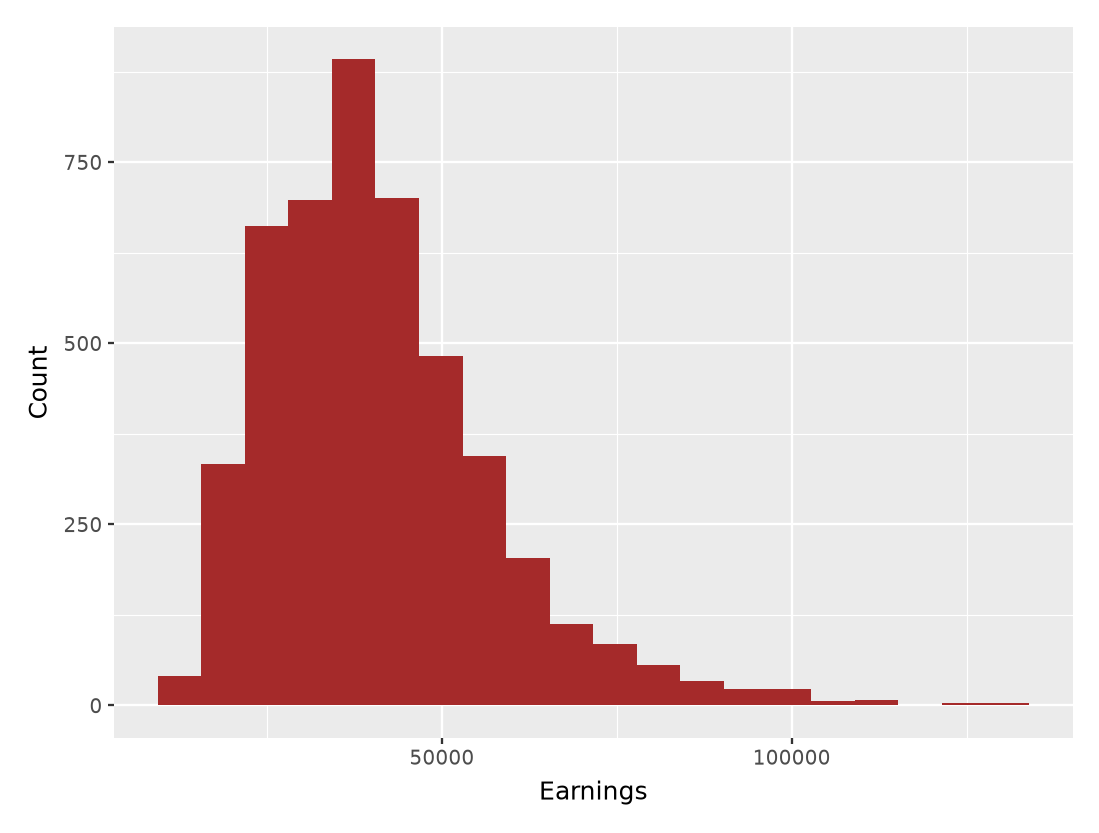

In [200]:
from plotnine import ggplot, aes, geom_histogram, labs

(
    ggplot(subset, aes(x="Median Earnings"))
    + geom_histogram(alpha=1, position="identity", fill="brown", bins = 20)
    + labs(
        x="Earnings",
        y="Count",
    )
)

5\. Create a new column with the log of earnings, then create a histogram. How does the shape of the histogram of log earnings compare to earnings itself?

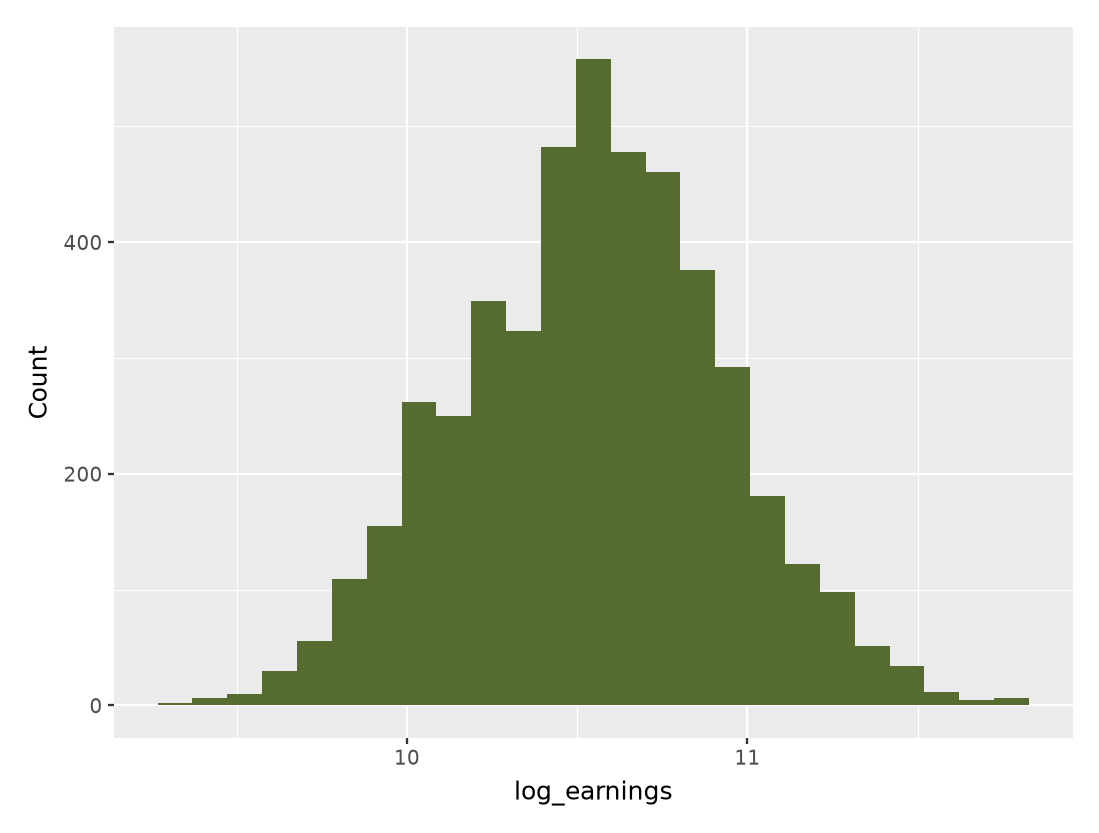

In [201]:
import numpy as np
subset["log_earnings"] = np.log(subset["Median Earnings"])

from plotnine import ggplot, aes, geom_histogram, labs

(
    ggplot(subset, aes(x="log_earnings"))
    + geom_histogram(alpha=1, position="identity", fill= "darkolivegreen", bins = 25)
    + labs(
        x="log_earnings",
        y="Count",
    )
)


6\. The mean gives every college equal weight. But some colleges are tiny (e.g., San Francisco Conservatory, with 228 undergraduates), while others are large (e.g., Penn State, with 72229 undergraduates!).

If we are interested in what *students* earn, we might want to give more weight to colleges with more students. To do this, we can calculate a **weighted mean**:

$$ \sum_{i=1}^n w_i x_i. $$

In general, the weights $w_1, w_2, ..., w_n$ should all be non-negative and should add up to $1.0$. (For the usual mean, every observation gets equal weight, $1/n$.)

Calculate a weighted mean of earnings, using the undergraduate enrollments as weights. Do this by first adding a "weight" column to the data set (number of undegraduates for the college divided by the total number of undergraduates in the data set).

In [202]:
total = np.sum(subset["Undergraduates"])
subset["weights"] = subset[["Undergraduates"]]/total

subset["weighted_earnings"] = subset["Median Earnings"] * subset["weights"]

subset[["weighted_earnings"]].sum()

weighted_earnings    50608.338313
dtype: float64

7\. Compute the mean of earnings for each state. Sort the states in descending order of mean earnings. Display the results in a bar chart.

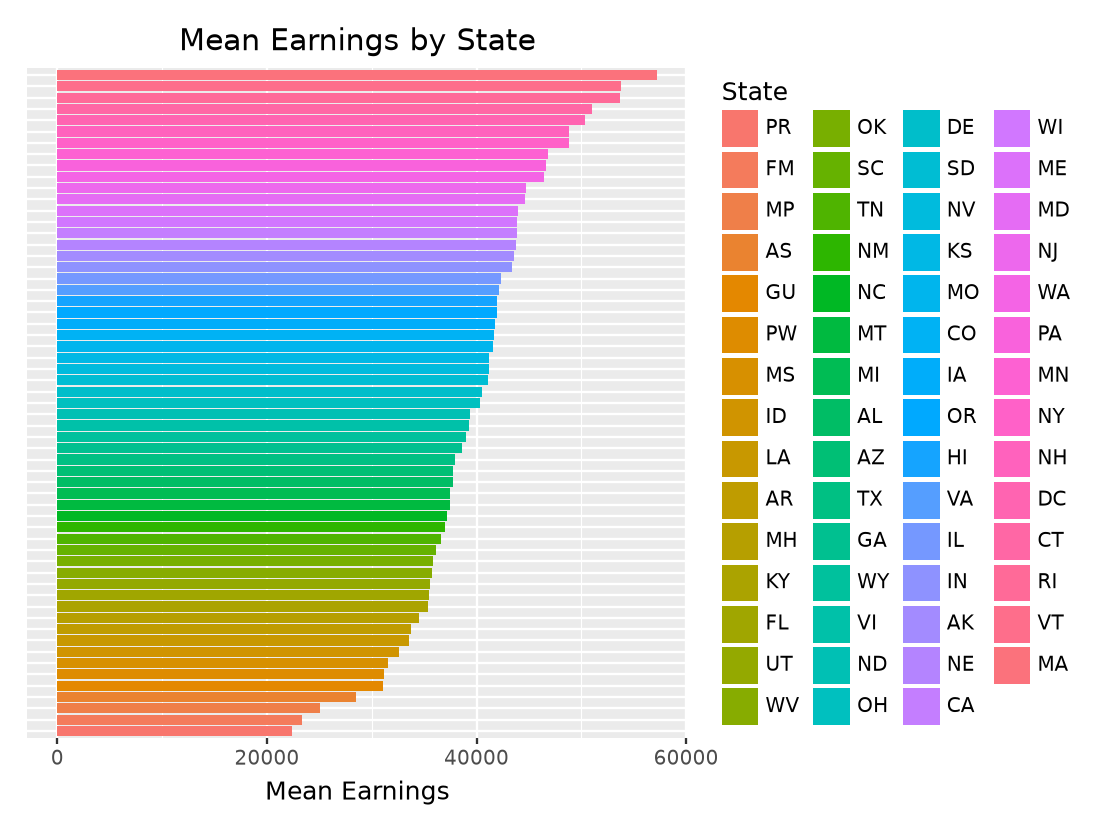

In [203]:
from plotnine import ggplot, aes, geom_col, coord_flip, labs, scale_fill_gradientn, guides, theme_minimal

state_mean = (
    subset.groupby("State", as_index=False)["Median Earnings"].mean().sort_values("Median Earnings", ascending=False)
)

state_mean["State"] = pd.Categorical(
    state_mean["State"],
    categories=state_mean["State"][::-1],
    ordered=True
)
from plotnine import *

(
    ggplot(state_mean, aes(
        x="State",
        y="Median Earnings",
        fill="State"
    ))
    + geom_col()
    + coord_flip()
    + scale_fill_hue()
    + labs(
        x="",
        y="Mean Earnings",
        title="Mean Earnings by State",
        fill="State"
    )
    + theme(
        axis_text_y=element_blank(),
        axis_ticks_major_y=element_blank()
    )
)

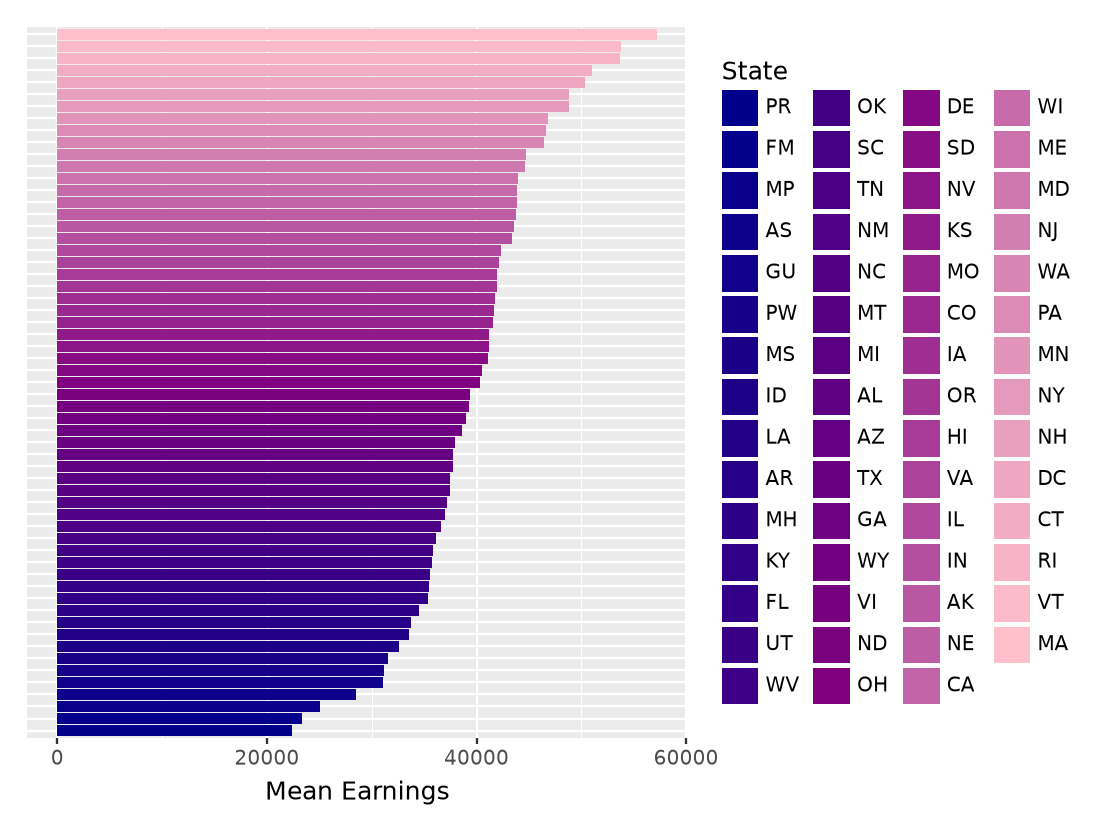

In [204]:
import matplotlib.colors as mcolors
from plotnine import scale_fill_manual

# Create one shade of blue for each state
n = state_mean["State"].nunique()

cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue_gradient",
    ["darkblue", "purple","pink"]
)

colors = [mcolors.to_hex(cmap(i / (n - 1))) for i in range(n)]

(
    ggplot(state_mean, aes(
        x="State",
        y="Median Earnings",
        fill="State"
    ))
    + geom_col()
    + coord_flip()
    + scale_fill_manual(values=colors)
    + labs(
        x="",
        y="Mean Earnings",
        fill="State"
    )
    + theme(
        axis_text_y=element_blank(),
        axis_ticks_major_y=element_blank()
    )
)

8\. Repeat the previous part, but now compute a weighted mean of earnings for each state, using the number of undegraduate enrollments in the state as weights. (Hint: use `groupby` with `transform`.)

In [205]:
# Total undergraduate enrollment within each state
subset["state_total_undergrads"] = (
    subset.groupby("State")["Undergraduates"].transform("sum")
)

# Weight of each college within its state
subset["state_weight"] = (
    subset["Undergraduates"] / subset["state_total_undergrads"]
)

# Weighted earnings contribution
subset["weighted_earnings"] = (
    subset["Median Earnings"] * subset["state_weight"]
)

# Weighted mean earnings for each state
state_weighted_mean = (
    subset.groupby("State", as_index=False)["weighted_earnings"]
    .sum()
    .sort_values("weighted_earnings", ascending=False)
)

state_weighted_mean

,State,weighted_earnings
8,DC,69939.367698
22,MA,65365.038613
46,RI,61382.901051
54,VT,58815.822129
7,CT,58515.071887
43,PA,58152.366783
39,NY,57869.188381
9,DE,56136.291687
23,MD,56049.152616
55,WA,55332.820949


## Olympic Men's Gymnastics Data



The file https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

In [206]:
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")

df_gym

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


1\. Create a data frame

- With [Round, Year, Gymnast] as the (multi) index, and
- Containing only the six columns with the event scores, "Floor Exercise" through "Pommelled Horse"

In [207]:
df_events = df_gym.set_index(["Round", "Year", "Gymnast"]).loc[:, "Floor Exercise":"Pommelled Horse"]
df_events

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva               15.100       15.500   
                   David Belyavsky            15.100       16.300   
                   Fabian HambÃ¼chen          15.133       15.833   
                   John Orozco                15.166       15.800   
                   Kristian Thomas            15.366       16.200   
...                                              ...          ...   
Final         2008 Daniel Keatings            14.850       15.800   
                   Thomas Bouhail             15.200       15.850   
                   José Luis Fuentes          14.175       15.250   
                   Dzmitry Savitski           13.725       15.900   
                   Chen Yibing                   NaN       15.900   

                                      Parallel Bars  Horizontal Bar   Rings  \
Round         Year Gymnast                                                    
Qualification 2012 Danell Leyva              15.333          15.866  14.600   
                   David Belyavsky           15.300          14.866  14.366   
                   Fabian HambÃ¼chen         15.300          15.633  14.766   
                   John Orozco               14.533          15.266  15.066   
                   Kristian Thomas           14.625          15.366  14.566   
...                                             ...             ...     ...   
Final         2008 Daniel Keatings           14.425          14.225  14.000   
                   Thomas Bouhail            14.425          14.475  13.650   
                   José Luis Fuentes         15.175          14.150  13.900   
                   Dzmitry Savitski          13.400          10.100  15.300   
                   Chen Yibing               14.950          12.975  16.650   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva                14.866  
                   David Belyavsky             14.900  
                   Fabian HambÃ¼chen           14.100  
                   John Orozco                 14.766  
                   Kristian Thomas             14.133  
...                                               ...  
Final         2008 Daniel Keatings             15.700  
                   Thomas Bouhail              13.400  
                   José Luis Fuentes           13.650  
                   Dzmitry Savitski            13.750  
                   Chen Yibing                 13.750  

[351 rows x 6 columns]

2\. Summarize the scores for each of the six events, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command!

In [208]:
df_events.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,324.000000,318.000000,325.000000
mean,14.309133,14.976551,14.719288,14.082562,14.237799,13.816723
std,1.254009,0.959876,0.920044,1.299542,0.914523,1.242348
min,1.633000,11.766000,10.200000,0.000000,7.700000,0.000000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.854000,14.831000,14.566000
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


3\. There are 351 rows in the data frame. Why are the sample sizes different for each event, and not all equal to 351?

**Some have null values**

4\. In the all around competition, each gymnast competes all six events, but this doesn't always happen (due to injury, etc). Therefore, there are some missing values in the data. Most of the missing values are coded as `NaN` but some are coded as 0. What would be a more appropriate way to code the missing values in this case: `NaN` or 0? Why?

**It would be more appropriate to code them as NaN because 0 is a valid score for a gymnast to achieve... if they do really poorly**

5\. Replace all scores of 0 in the data frame with `NaN`. (Note: It is possible to actually score a 0 on some events, e.g., if you do a vault but don't land feet first. But the few 0s in this data set are for people who didn't compete the event at all.)

In [209]:
import numpy as np

df_events = df_events.replace(0, np.nan)
        


6\. Summarize the revised data. Which events tend to have the highest scores? The lowest? Which events have the greatest degree of variability in scores? The least?

In [210]:
df_events.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,323.000000,318.000000,324.000000
mean,14.309133,14.976551,14.719288,14.126161,14.237799,13.859367
std,1.254009,0.959876,0.920044,1.037426,0.914523,0.977423
min,1.633000,11.766000,10.200000,9.433000,7.700000,10.666000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.858000,14.831000,14.574500
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


7\. Compute the correlation matrix. For which pairs of events is the correlation the highest? The lowest?

In [211]:
corr = df_events.corr()
corr

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Floor Exercise,1.000000,0.440092,0.351537,0.378685,0.494417,0.289385
Horse Vault,0.440092,1.000000,0.383301,0.500211,0.595005,0.367616
Parallel Bars,0.351537,0.383301,1.000000,0.557611,0.589963,0.481337
Horizontal Bar,0.378685,0.500211,0.557611,1.000000,0.491114,0.449014
Rings,0.494417,0.595005,0.589963,0.491114,1.000000,0.420985
Pommelled Horse,0.289385,0.367616,0.481337,0.449014,0.420985,1.000000


8\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.

In [212]:
df_events_standardized = (df_events - df_events.mean())/df_events.std()
df_events_standardized

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             0.630671     0.545330   
                   David Belyavsky          0.630671     1.378771   
                   Fabian HambÃ¼chen        0.656987     0.892250   
                   John Orozco              0.683303     0.857870   
                   Kristian Thomas          0.842791     1.274591   
...                                              ...          ...   
Final         2008 Daniel Keatings          0.431311     0.857870   
                   Thomas Bouhail           0.710416     0.909960   
                   José Luis Fuentes       -0.106963     0.284879   
                   Dzmitry Savitski        -0.465812     0.962050   
                   Chen Yibing                   NaN     0.962050   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            0.667047        1.677073  0.396055   
                   David Belyavsky         0.631179        0.713149  0.140184   
                   Fabian HambÃ¼chen       0.631179        1.452479  0.577570   
                   John Orozco            -0.202477        1.098718  0.905610   
                   Kristian Thomas        -0.102482        1.195111  0.358877   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.319863        0.095273 -0.260025   
                   Thomas Bouhail         -0.319863        0.336254 -0.642738   
                   José Luis Fuentes       0.495316        0.022979 -0.369372   
                   Dzmitry Savitski       -1.433940       -3.880914  1.161481   
                   Chen Yibing             0.250762       -1.109632  2.637661   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              1.029884  
                   David Belyavsky           1.064669  
                   Fabian HambÃ¼chen         0.246191  
                   John Orozco               0.927574  
                   Kristian Thomas           0.279953  
...                                               ...  
Final         2008 Daniel Keatings           1.883148  
                   Thomas Bouhail           -0.469978  
                   José Luis Fuentes        -0.214203  
                   Dzmitry Savitski         -0.111893  
                   Chen Yibing              -0.111893  

[351 rows x 6 columns]

9\. The all around champion is whoever has the highest total score for the six events (in the finals). But who is the "all around standardized value champion"? Create a column that sums the standardized values for each athlete, then sort the data frame in descending order by that column. Note: you should NOT have to manually add six columns.

In [213]:
df_events_standardized["total"] = df_events_standardized.sum(axis = 1)
df_events_standardized["total"].sort_values(ascending=False)

Round          Year  Gymnast         
Final          2008  Yang Wei             8.574298
Qualification  2008  Yang Wei             7.739403
Final          2012  Kohei Uchimura       6.485111
Qualification  2008  Kim Dae-Eun          6.206298
                     Li Xiaopeng          6.200877
                                           ...    
               2020  Uche Eke           -11.591600
                     David Huddleston   -11.919628
                     Hung Yuan-Hsi      -12.456954
                     David Rumbutis     -13.635800
                     Jeremiah Loo       -19.545795
Name: total, Length: 351, dtype: float64

10\. Compute the mean score for each event in each year. How do the means change over time? Why do you think this happened?

In [214]:

event_means = (df_gym.groupby("Year")
    [
        [
            "Floor Exercise",
            "Horse Vault",
            "Parallel Bars",
            "Horizontal Bar",
            "Rings",
            "Pommelled Horse"
        ]
    ]
    .mean()
)

event_means

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Year,,,,,,
2008,14.720250,15.841753,15.125758,14.563750,14.850532,14.248750
2012,14.495154,15.484308,14.663231,14.144908,14.441462,13.575062
2016,14.134667,14.496068,14.787083,14.246315,14.201514,14.051319
2020,13.841989,14.046398,14.242529,13.336919,13.453632,13.312341


11\. Choose one event and for that event create a plot with a single panel that summarizes the distribution of scores for each of the four years. Describe what you see.

C:\Users\copel\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_boxplot : Removed 28 rows containing non-finite values.


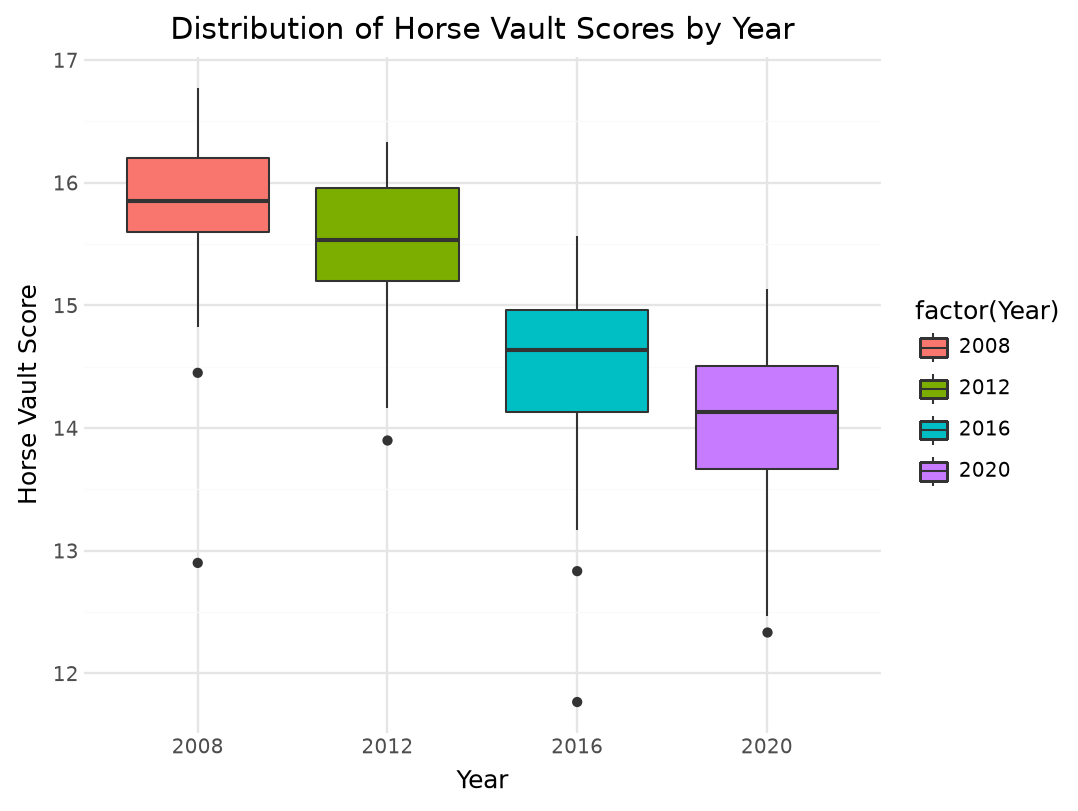

In [215]:
from plotnine import ggplot, aes, geom_boxplot, labs, theme_minimal

(
    ggplot(df_gym, aes(
        x="factor(Year)",
        y="Horse Vault",
        fill = "factor(Year)"
    ))
    + geom_boxplot()
    + labs(
        x="Year",
        y="Horse Vault Score",
        title="Distribution of Horse Vault Scores by Year",
        color = "Year"
    )
    + theme_minimal()
)

12\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation *within each year*. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.


In [216]:
df_standardized_score_within_year = (df_events - event_means.mean())/event_means.std()
df_standardized_score_within_year

Floor Exercise  Horse Vault  \
Round         Year Gymnast                                          
Qualification 2012 Danell Leyva             2.066613     0.636584   
                   David Belyavsky          2.066613     1.592292   
                   Fabian HambÃ¼chen        2.151650     1.034397   
                   John Orozco              2.236687     0.994974   
                   Kristian Thomas          2.752061     1.472829   
...                                              ...          ...   
Final         2008 Daniel Keatings          1.422395     0.994974   
                   Thomas Bouhail           2.324300     1.054706   
                   José Luis Fuentes       -0.316993     0.337925   
                   Dzmitry Savitski        -1.476586     1.114438   
                   Chen Yibing                   NaN     1.114438   

                                      Parallel Bars  Horizontal Bar     Rings  \
Round         Year Gymnast                                                      
Qualification 2012 Danell Leyva            1.722102        3.434061  0.618932   
                   David Belyavsky         1.631660        1.518830  0.220187   
                   Fabian HambÃ¼chen       1.631660        2.987812  0.901802   
                   John Orozco            -0.470437        2.284922  1.413013   
                   Kristian Thomas        -0.218295        2.476445  0.560995   
...                                             ...             ...       ...   
Final         2008 Daniel Keatings        -0.766430        0.291167 -0.403490   
                   Thomas Bouhail         -0.766430        0.769975 -0.999903   
                   José Luis Fuentes       1.289076        0.147525 -0.573894   
                   Dzmitry Savitski       -3.575621       -7.609159  1.811757   
                   Chen Yibing             0.672424       -2.102871  4.112207   

                                      Pommelled Horse  
Round         Year Gymnast                             
Qualification 2012 Danell Leyva              2.490381  
                   David Belyavsky           2.569578  
                   Fabian HambÃ¼chen         0.706100  
                   John Orozco               2.257446  
                   Kristian Thomas           0.782968  
...                                               ...  
Final         2008 Daniel Keatings           4.433057  
                   Thomas Bouhail           -0.924444  
                   José Luis Fuentes        -0.342107  
                   Dzmitry Savitski         -0.109172  
                   Chen Yibing              -0.109172  

[351 rows x 6 columns]

13\. If we standardize within each year, which athletes (and rounds and year) had the highest total standardized values? Basically repeat part 9 but with standardization within each year.

In [217]:
df_standardized_score_within_year["total"] = df_standardized_score_within_year.sum(axis = 1)
df_standardized_score_within_year["total"].sort_values(ascending=False)

Round          Year  Gymnast        
Final          2008  Yang Wei           17.025529
Qualification  2008  Yang Wei           15.311626
Final          2016  Kohei Uchimura     13.674905
                     Oleh Verniaiev     13.602984
Qualification  2008  Kim Dae-Eun        13.364726
                                          ...    
               2020  Hung Yuan-Hsi     -25.765778
                     David Rumbutis    -28.101655
               2008  Brandon O'Neill   -30.279183
               2016  Andreas Toba      -30.547635
               2020  Jeremiah Loo      -37.544081
Name: total, Length: 351, dtype: float64